In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix



Loading Mnist data from keras dataset


In [ ]:
mnist = tf.keras.datasets.mnist #this mnist conatin images of 28X28 from 0 to 9 digits

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


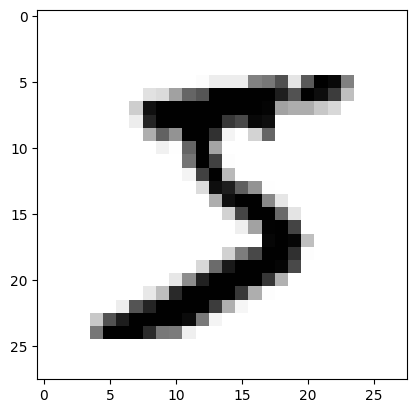

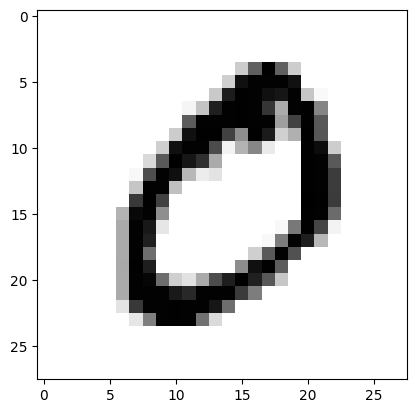

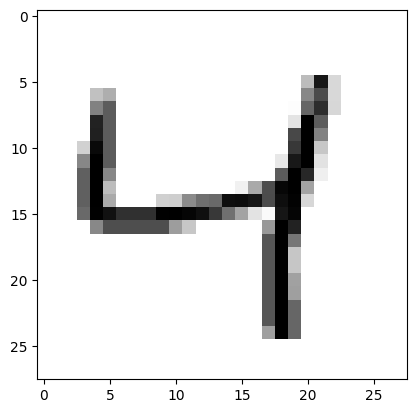

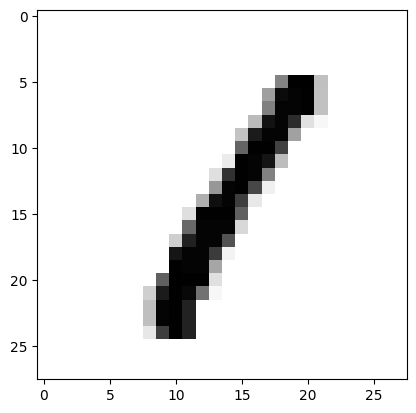

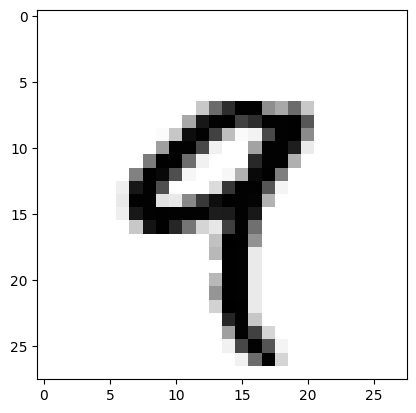

In [ ]:
x_train.shape
for i in range (0, 5):
    plt.imshow(x_train[i], cmap = plt.cm.binary)
    plt.show()

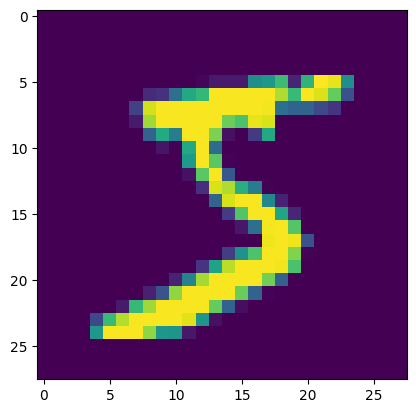

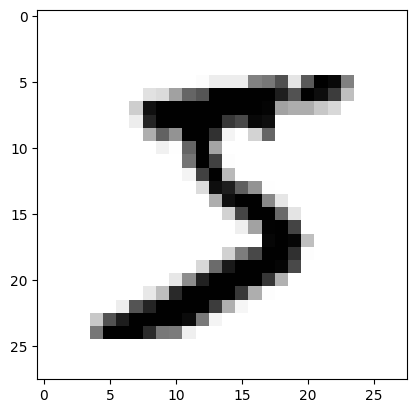

In [ ]:
plt.imshow(x_train[0])
plt.show()
#there is no RGB COLOR
#only the shades of grey (0 - 255)
#->black 255->white
plt.imshow(x_train[0], cmap = plt.cm.binary)

In [ ]:
print(x_train[0]) #before normalization

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

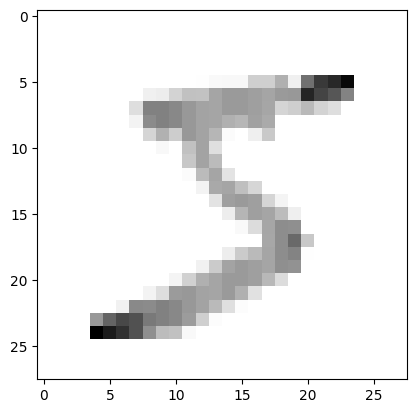

In [ ]:

#normalizing
x_train = tf.keras.utils.normalize(x_train, axis = 1)
x_test = tf.keras.utils.normalize(x_test, axis = 1)
plt.imshow(x_train[0], cmap = plt.cm.binary)


In [ ]:
print(x_train[4])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [ ]:
#resizing img to make it suitable for apply convolution operation
IMG_SIZE = 28
x_trainr = np.array(x_train).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
x_testr = np.array(x_test).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
print("Training Samples dimensions :", x_trainr.shape)
print("Testing Samples dimensions :", x_testr.shape)

Training Samples dimensions : (60000, 28, 28, 1)
Testing Samples dimensions : (10000, 28, 28, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D, Input

Creating a deep neural network


In [ ]:
# Creating a neural network
model = Sequential()

model.add(Input(shape=x_trainr.shape[1:]))
# First Convolution Layer
model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd Convolution Layer
model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3rd Convolution Layer
model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(64))
model.add(Activation("relu"))

model.add(Dense(32))
model.add(Activation("relu"))

# Output Layer
model.add(Dense(10))
model.add(Activation("softmax"))

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,066 (316.66 KB)

 Trainable params: 81,066 (316.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(x_trainr, y_train,epochs = 5, validation_split = 0.3)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 70s 51ms/step - accuracy: 0.7502 - loss: 0.7688 - val_accuracy: 0.9544 - val_loss: 0.1554
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 68s 52ms/step - accuracy: 0.9581 - loss: 0.1376 - val_accuracy: 0.9635 - val_loss: 0.1221
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 70s 54ms/step - accuracy: 0.9722 - loss: 0.0917 - val_accuracy: 0.9699 - val_loss: 0.1065
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 67s 51ms/step - accuracy: 0.9790 - loss: 0.0698 - val_accuracy: 0.9772 - val_loss: 0.0767
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 71s 54ms/step - accuracy: 0.9836 - loss: 0.0540 - val_accuracy: 0.9782 - val_loss: 0.0721


In [ ]:

test_loss, test_acc = model.evaluate(x_testr, y_test)
print("Test loss ion 10,000 test samples :", test_loss)
print("Validation Accuracy on 10,000 test samples : ", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9765 - loss: 0.0796
Test loss ion 10,000 test samples : 0.06989636272192001
Validation Accuracy on 10,000 test samples :  0.9787999987602234


In [ ]:
model.save("mnist_cnn_model.h5")


In [ ]:
model.save("digit_recognition_model.keras")

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Screenshot 2025-12-26 233838.png to Screenshot 2025-12-26 233838 (1).png


(np.float64(-0.5), np.float64(296.5), np.float64(342.5), np.float64(-0.5))

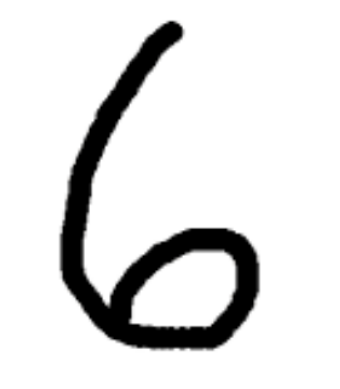

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(list(uploaded.keys())[0])
plt.imshow(img)
plt.axis('off')


In [ ]:
from PIL import Image
import numpy as np
import cv2

img = Image.open(list(uploaded.keys())[0])
img = img.convert("L")
img = img.resize((28,28))
img = np.array(img)

# invert
img = 255 - img

# threshold
img = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY)[1]

# normalize
img = img / 255.0

# reshape
img = img.reshape(1,28,28,1)


In [ ]:
pred = model.predict(img)

print("Predicted digit:", np.argmax(pred))
print("Confidence:", np.max(pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted digit: 6
Confidence: 1.0
